# DEGWO (Differential Evolution – Grey Wolf Optimizer)
## Sensor: HMP155A Temperature 
---

## Cell 1 — Import Libraries

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import collections
import warnings
import time
import os

from scipy import stats
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

warnings.filterwarnings('ignore')
tf.get_logger().setLevel('ERROR')

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("=== Library Import Selesai ===")
print(f"TensorFlow version : {tf.__version__}")
print(f"NumPy version      : {np.__version__}")
print(f"Pandas version     : {pd.__version__}")

=== Library Import Selesai ===
TensorFlow version : 2.20.0
NumPy version      : 2.0.2
Pandas version     : 2.2.2


## Cell 2 — Load & Pre-process Data

In [ ]:
# ─── Load CSV ───────────────────────────────────────────────────
FILE_PATH = 'Grafik Suhu-data-2025-07-08 11_55_01.csv'
df = pd.read_csv(FILE_PATH)

sensor_cols = ['HMP155A', 'EYC', 'HygroVUE', 'TA T107', 'TS T107']
for col in sensor_cols:
    if col in df.columns:
        df[col] = df[col].str.replace(' °C', '', regex=False).astype(float)

# Parse waktu dan konversi ke UTC+7
df['Time'] = pd.to_datetime(df['Time'])
df['Time'] = df['Time'].dt.tz_localize('UTC').dt.tz_convert('Asia/Jakarta').dt.tz_localize(None)
df = df.set_index('Time').sort_index()

df = df.drop(columns=['TS T107'])

duplicate_index = df[df.index.duplicated(keep=False)]
jumlah_index_duplikat = df.index.duplicated().sum()

print("\n=== Info Duplikat ===")
print(f"Jumlah index identik (waktu sama)        : {jumlah_index_duplikat}")

print("\n=== Hasil Duplikat Index (Waktu) ===")
if not duplicate_index.empty:
    print(duplicate_index)
else:
    print("Tidak ada waktu (index) yang duplikat.")

if jumlah_index_duplikat > 0:
    print(f"Sedang memproses {jumlah_index_duplikat} waktu duplikat...")

    df = df.groupby(df.index).mean()
    print("Beres!")

    cek_lagi = df.index.duplicated().sum()
    print(f"Jumlah duplikat sekarang: {cek_lagi}")
else:
    print("Data sudah unik, tidak perlu dihandling.")

print("\n=== Dataset Setelah Handling ===")
print(f"Total baris        : {len(df)}")
print(df)


=== Info Duplikat ===
Jumlah index identik (waktu sama)        : 47

=== Hasil Duplikat Index (Waktu) ===
                     HMP155A   EYC  HygroVUE  TA T107
Time                                                 
2023-07-26 13:36:41     18.5  19.7       0.0     18.8
2023-07-26 13:36:41     18.4  19.3       0.0     18.6
2023-08-03 00:45:12      9.5   9.5      10.4      9.4
2023-08-03 00:45:12      9.2   9.3      10.1      9.1
2023-08-03 00:45:12      8.9   9.0       9.8      8.8
...                      ...   ...       ...      ...
2024-04-19 14:02:27     18.0  18.3      18.4     18.2
2024-04-21 15:54:36     17.3  17.2      17.0     17.2
2024-04-21 15:54:36     17.4  17.3      17.1     17.3
2024-05-21 13:10:30     18.9  19.0      18.8     19.3
2024-05-21 13:10:30     19.4  19.2      18.8     19.2

[76 rows x 4 columns]
Sedang memproses 47 waktu duplikat...
Beres!
Jumlah duplikat sekarang: 0

=== Dataset Setelah Handling ===
Total baris        : 537718
                     HMP155A   EY

In [ ]:
df_sensor = df[['HMP155A']].copy()

print("=== Info Dataset ===")
print(f"Total baris        : {len(df_sensor)}")
print(f"Rentang waktu      : {df_sensor.index[0]}  →  {df_sensor.index[-1]}")
print(f"Missing values     : {df_sensor.isnull().sum().values[0]}")
print(f"Min Suhu           : {df_sensor['HMP155A'].min():.2f} °C")
print(f"Max Suhu           : {df_sensor['HMP155A'].max():.2f} °C")
print(f"Mean Suhu          : {df_sensor['HMP155A'].mean():.2f} °C")

df_sensor

=== Info Dataset ===
Total baris        : 537718
Rentang waktu      : 2023-05-01 07:01:30  →  2024-05-31 06:59:23
Missing values     : 0
Min Suhu           : -1.40 °C
Max Suhu           : 23.30 °C
Mean Suhu          : 14.57 °C


,HMP155A
Time,
2023-05-01 07:01:30,15.9
2023-05-01 07:02:30,15.7
2023-05-01 07:03:30,15.7
2023-05-01 07:04:30,15.8
2023-05-01 07:05:30,16.0
...,...
2024-05-31 06:55:23,11.9
2024-05-31 06:56:23,11.7
2024-05-31 06:57:23,11.8


## Cell 3 — Train/Validation/Test Split & Normalization

In [31]:
total     = len(df_sensor)
train_end = int(total * 0.60)
val_end   = int(total * 0.80)

train_data = df_sensor.iloc[:train_end]
val_data   = df_sensor.iloc[train_end:val_end]
test_data  = df_sensor.iloc[val_end:]

print("=== Ukuran Split ===")
print(f"Training   : {len(train_data):>6} baris | {train_data.index[0]}  →  {train_data.index[-1]}")
print(f"Validation : {len(val_data):>6} baris | {val_data.index[0]}  →  {val_data.index[-1]}")
print(f"Test       : {len(test_data):>6} baris | {test_data.index[0]}  →  {test_data.index[-1]}")

# Normalisasi — fit HANYA dari training set
scaler        = MinMaxScaler()
train_scaled  = scaler.fit_transform(train_data)
val_scaled    = scaler.transform(val_data)
test_scaled   = scaler.transform(test_data)

print("\n=== Statistik Setelah Normalisasi ===")
print(f"Train  — Min: {train_scaled.min():.4f}, Max: {train_scaled.max():.4f}")
print(f"Val    — Min: {val_scaled.min():.4f}, Max: {val_scaled.max():.4f}")
print(f"Test   — Min: {test_scaled.min():.4f}, Max: {test_scaled.max():.4f}")

=== Ukuran Split ===
Training   : 322630 baris | 2023-05-01 07:01:30  →  2023-12-20 07:53:26
Validation : 107544 baris | 2023-12-20 07:54:26  →  2024-03-17 05:50:24
Test       : 107544 baris | 2024-03-17 05:51:24  →  2024-05-31 06:59:23

=== Statistik Setelah Normalisasi ===
Train  — Min: 0.0000, Max: 1.0000
Val    — Min: 0.1822, Max: 0.9595
Test   — Min: 0.2753, Max: 0.9879


## Cell 4 — Sliding Window Sequence Creation

In [32]:
WINDOW_SIZE = 60  # 60 menit terakhir untuk prediksi 1 langkah ke depan

def create_sequences(data, window_size=60):
    """Buat sliding window sequences.
    X : (samples, window_size, 1)  — historical time-series
    y : (samples, 1)               — next-step actual value
    """
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i : i + window_size])
        y.append(data[i + window_size])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_scaled, WINDOW_SIZE)
X_val,   y_val   = create_sequences(val_scaled,   WINDOW_SIZE)
X_test,  y_test  = create_sequences(test_scaled,  WINDOW_SIZE)

print("=== Shape Sequences ===")
print(f"X_train : {X_train.shape}   y_train : {y_train.shape}")
print(f"X_val   : {X_val.shape}     y_val   : {y_val.shape}")
print(f"X_test  : {X_test.shape}    y_test  : {y_test.shape}")
print(f"\nWindow size (independent variable X) : last {WINDOW_SIZE} minutes")
print(f"Target     (dependent variable   y) : next-step HMP155A temperature")

=== Shape Sequences ===
X_train : (322570, 60, 1)   y_train : (322570, 1)
X_val   : (107484, 60, 1)     y_val   : (107484, 1)
X_test  : (107484, 60, 1)    y_test  : (107484, 1)

Window size (independent variable X) : last 60 minutes
Target     (dependent variable   y) : next-step HMP155A temperature


## Cell 5 — DEGWO Optimizer Definition

**Differential Evolution – Grey Wolf Optimizer (DEGWO)**

Hyperparameter search space:
| Hyperparameter | Range |
|---|---|
| BiLSTM units | [16, 128] |
| Dropout rate | [0.1, 0.5] |
| Learning rate | [1e-4, 1e-2] |
| Batch size | [32, 256] |

In [ ]:
# ═══════════════════════════════════════════════════════════════════
# DEGWO HYPERPARAMETER SEARCH SPACE
# ═══════════════════════════════════════════════════════════════════
# Dimensions: [units, dropout, learning_rate, batch_size]
BOUNDS_LOW  = np.array([16,   0.1,  1e-4,  32])
BOUNDS_HIGH = np.array([256,  0.5,  1e-3,  256])
DIM = len(BOUNDS_LOW)

def decode_position(pos):
    pos = np.clip(pos, BOUNDS_LOW, BOUNDS_HIGH)
    units      = int(round(pos[0] / 8) * 8)
    units      = max(8, min(256, units))
    dropout    = float(np.clip(pos[1], 0.1, 0.5))
    lr         = float(np.clip(pos[2], 1e-4, 1e-3))
    batch_size = int(round(pos[3] / 32) * 32)
    batch_size = max(32, min(256, batch_size))
    return {'units': units, 'dropout': dropout, 'lr': lr, 'batch_size': batch_size}


def fitness_function(pos):
    """Build & train a BiLSTM with given hyperparameters. Return val MSE."""
    hp = decode_position(pos)

    tf.keras.backend.clear_session()
    model = Sequential([
        Bidirectional(LSTM(hp['units']), input_shape=(WINDOW_SIZE, 1)),
        Dropout(hp['dropout']),
        Dense(1)
    ])
    model.compile(
        optimizer=Adam(learning_rate=hp['lr']),
        loss='mse'
    )

    early_stop = EarlyStopping(monitor='val_loss', patience=5,
                               restore_best_weights=True, verbose=0)
    history = model.fit(
        X_train, y_train,
        epochs=20,                       # small epochs for optimization speed
        batch_size=hp['batch_size'],
        validation_data=(X_val, y_val),
        callbacks=[early_stop],
        verbose=0
    )

    val_mse = min(history.history['val_loss'])
    return val_mse


# ═══════════════════════════════════════════════════════════════════
# DEGWO ALGORITHM
# ═══════════════════════════════════════════════════════════════════
def degwo(n_agents=5, max_iter=10, F=0.5, CR=0.7, verbose=True):
    """
    Differential Evolution - Grey Wolf Optimizer (DEGWO)

    Parameters
    ----------
    n_agents : int   — Population size (N)
    max_iter : int   — Maximum iterations (T)
    F        : float — Differential weight
    CR       : float — Crossover probability
    verbose  : bool  — Print progress

    Returns
    -------
    best_pos      : np.ndarray  — Best position (hyperparameter vector)
    best_fitness  : float       — Best fitness (val MSE)
    convergence   : list        — Best fitness per iteration
    """

    # ── Step 1: Initialize population randomly ────────────────────
    X = np.random.uniform(
        low=BOUNDS_LOW, high=BOUNDS_HIGH,
        size=(n_agents, DIM)
    )

    # ── Step 2: Initialize parameters ────────────────────────────
    fitness = np.full(n_agents, np.inf)

    # ── Step 3: Evaluate initial fitness ─────────────────────────
    if verbose:
        print("[DEGWO] Evaluating initial population...")

    for i in range(n_agents):
        fitness[i] = fitness_function(X[i])
        if verbose:
            hp = decode_position(X[i])
            print(f"  Agent {i+1:02d} | fitness={fitness[i]:.6f} | "
                  f"units={hp['units']}, dropout={hp['dropout']:.2f}, "
                  f"lr={hp['lr']:.5f}, batch={hp['batch_size']}")

    # ── Step 4: Initial update of Alpha, Beta, Delta ─────────────
    # Sort agents by fitness
    sorted_idx = np.argsort(fitness)
    X_alpha = X[sorted_idx[0]].copy()
    X_beta  = X[sorted_idx[1]].copy()
    X_delta = X[sorted_idx[2]].copy()
    f_alpha = fitness[sorted_idx[0]]

    # Track per-agent best positions (Xibest)
    X_best     = X.copy()
    f_best     = fitness.copy()

    # Global best
    X_star     = X_alpha.copy()
    f_star     = f_alpha

    convergence = [f_star]

    if verbose:
        print(f"\n[DEGWO] Initial best fitness: {f_star:.6f}")
        print(f"  Alpha → units={decode_position(X_alpha)['units']}, "
              f"dropout={decode_position(X_alpha)['dropout']:.2f}, "
              f"lr={decode_position(X_alpha)['lr']:.5f}, "
              f"batch={decode_position(X_alpha)['batch_size']}")
        print("-" * 60)

    # ── Main Loop ─────────────────────────────────────────────────
    for t in range(1, max_iter + 1):
        t_start = time.time()

        # ── Step 5: Update a, A, C ────────────────────────────────
        a = 2.0 - 2.0 * t / max_iter

        new_X    = X.copy()
        new_fitness = fitness.copy()

        # ── Steps 6–9: For each agent ────────────────────────────
        for i in range(n_agents):

            # ── Step 5: Random r1, r2 per agent ──────────────────
            # r1 = np.random.rand(DIM)
            # r2 = np.random.rand(DIM)

            A1 = 2.0 * a * np.random.rand(DIM) - a
            A2 = 2.0 * a * np.random.rand(DIM) - a
            A3 = 2.0 * a * np.random.rand(DIM) - a

            C1 = 2.0 * np.random.rand(DIM)
            C2 = 2.0 * np.random.rand(DIM)
            C3 = 2.0 * np.random.rand(DIM)

            # ── Step 8: GWO position update ───────────────────────
            # D vectors
            D_alpha = np.abs(C1 * X_alpha - X[i])
            D_beta  = np.abs(C2 * X_beta  - X[i])
            D_delta = np.abs(C3 * X_delta - X[i])

            # Xi1, Xi2, Xi3
            Xi1 = X_alpha - A1 * D_alpha
            Xi2 = X_beta  - A2 * D_beta
            Xi3 = X_delta - A3 * D_delta

            W_i = (Xi1 + Xi2 + Xi3) / 3.0

            # ── Step 7: DE mutation ───────────────────────────────
            candidates = [k for k in range(n_agents) if k != i]
            a_idx, b_idx = np.random.choice(candidates, size=2, replace=False)

            V_i = X_alpha + F * (X_best[a_idx] - X_best[b_idx])

            # ── Step 9: Crossover — Eq.(14) ───────────────────────
            R_j = np.random.randint(0, DIM)         # guaranteed dimension
            r_j = np.random.rand(DIM)
            U_i = np.where((r_j <= CR) | (np.arange(DIM) == R_j), V_i, X[i])

            # Clip to bounds
            U_i = np.clip(U_i, BOUNDS_LOW, BOUNDS_HIGH)

            # Evaluate U_i
            f_ui = fitness_function(U_i)

            # Greedy selection — keep better solution (Algorithm block)
            if f_ui < fitness[i]:
                new_X[i]       = U_i
                new_fitness[i] = f_ui
                # Update per-agent best (Xibest)
                if f_ui < f_best[i]:
                    X_best[i] = U_i.copy()
                    f_best[i] = f_ui
                # Update global best (X*)
                if f_ui < f_star:
                    X_star  = U_i.copy()
                    f_star  = f_ui
            else:
                new_X[i]       = X[i]
                new_fitness[i] = fitness[i]

        # ── Update population ─────────────────────────────────────
        X       = new_X
        fitness = new_fitness

        # ── Sort & update Alpha, Beta, Delta ─────────────────────
        sorted_idx = np.argsort(fitness)           # s = sort(f)
        X_alpha    = X[sorted_idx[0]].copy()       # Xα = Xs1
        X_beta     = X[sorted_idx[1]].copy()       # Xβ = Xs2
        X_delta    = X[sorted_idx[2]].copy()       # Xδ = Xs3
        f_alpha    = fitness[sorted_idx[0]]

        if f_alpha < f_star:
            X_star = X_alpha.copy()
            f_star = f_alpha

        convergence.append(f_star)

        elapsed = time.time() - t_start
        if verbose:
            hp_best = decode_position(X_star)
            print(f"[Iter {t:02d}/{max_iter}] best_fitness={f_star:.6f} | "
                  f"units={hp_best['units']}, dropout={hp_best['dropout']:.2f}, "
                  f"lr={hp_best['lr']:.5f}, batch={hp_best['batch_size']} | "
                  f"elapsed={elapsed:.1f}s")

    # ── Step 11–12: Extract best hyperparameters ──────────────────
    best_hp = decode_position(X_star)

    return X_star, f_star, convergence, best_hp


print("=== DEGWO Definition Selesai ===")
print(f"Dimensi pencarian  : {DIM} (units, dropout, lr, batch_size, epochs)")
print(f"Batas bawah        : {BOUNDS_LOW}")
print(f"Batas atas         : {BOUNDS_HIGH}")

=== DEGWO Definition Selesai ===
Dimensi pencarian  : 4 (units, dropout, lr, batch_size, epochs)
Batas bawah        : [1.6e+01 1.0e-01 1.0e-04 3.2e+01]
Batas atas         : [2.56e+02 5.00e-01 1.00e-03 2.56e+02]


## Cell 6 — Run DEGWO Optimization

> **Note:** Atur `N_AGENTS` dan `MAX_ITER` sesuai kebutuhan.  
> Nilai kecil (e.g., 5 agents × 10 iter) untuk uji cepat; nilai besar untuk hasil optimal.  

In [ ]:
# ═══════════════════════════════════════════════════
# DEGWO CONFIGURATION
# ═══════════════════════════════════════════════════
N_AGENTS = 5      # Population size N
MAX_ITER = 10     # Maximum iterations T
F_DE     = 0.5    # Differential weight
CR_DE    = 0.7    # Crossover probability

print("=" * 60)
print("        DEGWO — Hyperparameter Optimization")
print("=" * 60)
print(f"  Population size (N)       : {N_AGENTS}")
print(f"  Maximum iterations (T)    : {MAX_ITER}")
print(f"  Differential weight (F)   : {F_DE}")
print(f"  Crossover probability (CR): {CR_DE}")
print(f"  Total fitness evaluations : ~{N_AGENTS + N_AGENTS * MAX_ITER}")
print("=" * 60)
print()

start_time = time.time()

best_pos, best_fitness, convergence_curve, best_hp = degwo(
    n_agents = N_AGENTS,
    max_iter = MAX_ITER,
    F        = F_DE,
    CR       = CR_DE,
    verbose  = True
)

total_time = time.time() - start_time

print()
print("=" * 60)
print("        DEGWO — OPTIMIZATION COMPLETE")
print("=" * 60)
print(f"  Total waktu optimasi  : {total_time/60:.1f} menit")
print(f"  Best Fitness (Val MSE): {best_fitness:.6f}")
print()
print("  ── Optimal Hyperparameters (X*) ──")
print(f"  BiLSTM Units     : {best_hp['units']}")
print(f"  Dropout Rate     : {best_hp['dropout']:.4f}")
print(f"  Learning Rate    : {best_hp['lr']:.6f}")
print(f"  Batch Size       : {best_hp['batch_size']}")
print("=" * 60)

        DEGWO — Hyperparameter Optimization
  Population size (N)       : 5
  Maximum iterations (T)    : 10
  Differential weight (F)   : 0.5
  Crossover probability (CR): 0.7
  Total fitness evaluations : ~55

[DEGWO] Evaluating initial population...
  Agent 01 | fitness=0.000032 | units=104, dropout=0.48, lr=0.00076, batch=160
  Agent 02 | fitness=0.000033 | units=56, dropout=0.16, lr=0.00015, batch=224
  Agent 03 | fitness=0.000036 | units=160, dropout=0.38, lr=0.00012, batch=256
  Agent 04 | fitness=0.000030 | units=216, dropout=0.18, lr=0.00026, batch=64
  Agent 05 | fitness=0.000032 | units=88, dropout=0.31, lr=0.00049, batch=96

[DEGWO] Initial best fitness: 0.000030
  Alpha → units=216, dropout=0.18, lr=0.00026, batch=64
------------------------------------------------------------
[Iter 01/10] best_fitness=0.000030 | units=240, dropout=0.12, lr=0.00012, batch=96 | elapsed=4236.7s
[Iter 02/10] best_fitness=0.000029 | units=256, dropout=0.11, lr=0.00010, batch=96 | elapsed=5465.

## Cell 7 — Plot Convergence Curve (DEGWO)

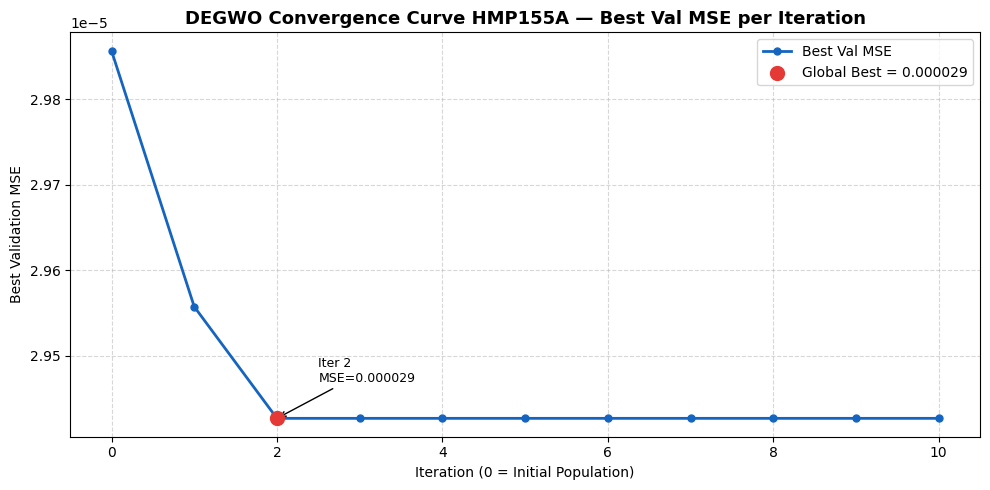

Plot convergence disimpan: degwo_convergence.png


In [ ]:
# ── Step 13: Plot convergence ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(range(len(convergence_curve)), convergence_curve,
        color='#1565C0', linewidth=2, marker='o', markersize=5, label='Best Val MSE')

ax.scatter([np.argmin(convergence_curve)], [min(convergence_curve)],
           color='#E53935', zorder=5, s=100, label=f'Global Best = {min(convergence_curve):.6f}')

ax.set_title('DEGWO Convergence Curve HMP155A — Best Val MSE per Iteration',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Iteration (0 = Initial Population)')
ax.set_ylabel('Best Validation MSE')
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.5)

# Annotate best
best_iter = int(np.argmin(convergence_curve))
ax.annotate(
    f'Iter {best_iter}\nMSE={min(convergence_curve):.6f}',
    xy=(best_iter, min(convergence_curve)),
    xytext=(best_iter + 0.5, min(convergence_curve) + (max(convergence_curve)-min(convergence_curve))*0.1),
    arrowprops=dict(arrowstyle='->', color='black'),
    fontsize=9
)

plt.tight_layout()
plt.savefig('degwo_convergence.png', dpi=150)
plt.show()
print("Plot convergence disimpan: degwo_convergence.png")